In [179]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":   0.6,
    "lines.linewidth":  0.9,
    "legend.frameon":   False,
    "legend.fontsize":  9,
})

In [180]:
import json
import pandas as pd
from pathlib import Path

FOLDER = Path(r"C:\Users\kdmen\OneDrive\Desktop\Spring26\MAML_MOE_NeurIPS26\raw_results\paper_fixed_trts_split_jsons")
USERS_TO_KEEP = ['P004', 'P104', 'P105', 'P121']

# Ablations where results are stored under 'result' key with ft subkeys
FT_ABLATIONS = {'A1', 'A2', 'A11'}  # head_only + full_ft structure

def infer_ablation_id(filename: str) -> str:
    parts = filename.split('_')
    if parts[0] == 'grid':
        if parts[1] == 'A2':
            return '_'.join(parts[:4])   # e.g. grid_A2_k5_n10
        return '_'.join(parts[:3])       # e.g. grid_k5_n10
    elif parts[0] == 'A5':
        return '_'.join(parts[:2])       # e.g. A5_E4
    else:
        return parts[0]                  # e.g. A1, A2, M0
    
def make_row(ablation_id: str, ft_label: str, user_accs: dict) -> dict:
    all_kept_accs = list(user_accs.values())
    return {
        'Ablation_ID':     ablation_id,
        'Finetune_Method': ft_label,
        **user_accs,
        'Mean':            pd.Series(all_kept_accs).mean(),
        'Median':          pd.Series(all_kept_accs).median(),
        'Std':             pd.Series(all_kept_accs).std(),
    }
    
def parse_top_level_ft_file(data: dict, ablation_id: str) -> list[dict]:
    """For A7: ft keys live at top level with per_subject_head_acc / per_subject_full_acc."""
    rows = []
    for key, ft_label in [('per_subject_head_acc', 'head'), ('per_subject_full_acc', 'full')]:
        per_user = data[key]
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_top_level_maml_file(data: dict, ablation_id: str) -> list[dict]:
    """For A8: MAML result lives at top level under per_subject_mean."""
    rows = []
    for key, ft_label in [('per_subject_mean', 'MAML')]:
        per_user = data[key]
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_ft_file(result: dict, ablation_id: str) -> list[dict]:
    """For FT_ABLATIONS (A1, A2, A11): ft keys live under data['result'] with per_user_acc subkey."""
    rows = []
    for ft_key, ft_label in [('test_head_only', 'head'), ('test_full_ft', 'full')]:
        ft_data = result[ft_key]
        per_user = ft_data['per_user_acc']
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_top_level_ft_per_user_file(data: dict, ablation_id: str) -> list[dict]:
    """For grid_A2_kx: ft keys live at top level (not under 'result') with per_user_acc subkey."""
    rows = []
    for ft_key, ft_label in [('test_head_only', 'head'), ('test_full_ft', 'full')]:
        ft_data = data[ft_key]
        per_user = ft_data['per_user_acc']
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_maml_file(result: dict, ablation_id: str) -> list[dict]:
    per_user = result['per_user_acc']
    user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
    return [make_row(ablation_id, 'MAML', user_accs)]

rows = []
for json_file in sorted(FOLDER.glob("*.json")):
    ablation_id = infer_ablation_id(json_file.name)

    with open(json_file) as f:
        data = json.load(f)

    if ablation_id in FT_ABLATIONS:
        result = data['result']
        rows.extend(parse_ft_file(result, ablation_id))
    elif ablation_id == 'A7':
        rows.extend(parse_top_level_ft_file(data, ablation_id))
    elif ablation_id == 'A8':
        rows.extend(parse_top_level_maml_file(data, ablation_id))
    elif ablation_id.startswith('grid_A2'):
        # Top-level ft structure (test_head_only / test_full_ft) with per_user_acc subkey
        rows.extend(parse_top_level_ft_per_user_file(data, ablation_id))
    else:
        # A5 and remaining grids use 'test_results'; A4, M0, and others use 'result'
        if ablation_id.startswith('A5') or ablation_id.startswith('grid'):
            result = data['test_results']
        elif ablation_id == 'A4':
            result = data['fold_results'][0]['test_results']
        elif ablation_id == 'M0':
            result = data['result']['test_results']
        else:
            result = data['result']
        rows.extend(parse_maml_file(result, ablation_id))

df = pd.DataFrame(rows, columns=['Ablation_ID', 'Finetune_Method'] + USERS_TO_KEEP + ['Mean', 'Median', 'Std'])
print(df.shape)
df.head(100)

(46, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A11,head,0.852917,0.751417,0.797667,0.760833,0.790708,0.779250,0.046024
1,A11,full,0.359333,0.348083,0.383500,0.354833,0.361438,0.357083,0.015418
2,A1,head,0.775583,0.799000,0.721833,0.807667,0.776021,0.787292,0.038583
3,A1,full,0.935333,0.885333,0.902750,0.906500,0.907479,0.904625,0.020733
4,A2,head,0.772500,0.784083,0.762417,0.701833,0.755208,0.767458,0.036668
5,A2,full,0.937417,0.903000,0.914083,0.936333,0.922708,0.925208,0.016978
6,A4,MAML,0.852750,0.827833,0.757750,0.914333,0.838167,0.840292,0.064776
7,A5_E12,MAML,0.924417,0.886417,0.875250,0.907750,0.898458,0.897083,0.021938
8,A5_E16,MAML,0.922167,0.885000,0.875250,0.908083,0.897625,0.896542,0.021383
9,A5_E20,MAML,0.926333,0.851417,0.904333,0.918333,0.900104,0.911333,0.033708


In [181]:
mask_a5   = df['Ablation_ID'].str.startswith('A5')
mask_grid = df['Ablation_ID'].str.startswith('grid')

In [182]:
df_a5   = df[mask_a5].reset_index(drop=True)
print(df_a5.shape)
df_a5.head(20)

(8, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A5_E12,MAML,0.924417,0.886417,0.875250,0.907750,0.898458,0.897083,0.021938
1,A5_E16,MAML,0.922167,0.885000,0.875250,0.908083,0.897625,0.896542,0.021383
2,A5_E20,MAML,0.926333,0.851417,0.904333,0.918333,0.900104,0.911333,0.033708
3,A5_E24,MAML,0.973833,0.881000,0.896000,0.945667,0.924125,0.920833,0.043150
4,A5_E32,MAML,0.885250,0.860500,0.850833,0.882000,0.869646,0.871250,0.016670
5,A5_E40,MAML,0.899750,0.888000,0.841750,0.880750,0.877563,0.884375,0.025126
6,A5_E4,MAML,0.842333,0.814250,0.827167,0.829500,0.828313,0.828333,0.011505
7,A5_E8,MAML,0.937917,0.913083,0.923333,0.918917,0.923312,0.921125,0.010603


In [183]:
df_grid = df[mask_grid].reset_index(drop=True)
print(df_grid.shape)
df_grid.head(100)

(27, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,grid_A2_k1_n10,head,0.425556,0.406311,0.412578,0.346644,0.397772,0.409444,0.035015
1,grid_A2_k1_n10,full,0.754644,0.638244,0.599956,0.662889,0.663933,0.650567,0.065784
2,grid_A2_k1_n3,head,0.760222,0.746593,0.777556,0.647037,0.732852,0.753407,0.058596
3,grid_A2_k1_n3,full,0.920074,0.892370,0.906963,0.915333,0.908685,0.911148,0.012152
4,grid_A2_k1_n5,head,0.639156,0.590444,0.644178,0.520222,0.598500,0.614800,0.057537
5,grid_A2_k1_n5,full,0.860089,0.797556,0.799333,0.836800,0.823444,0.818067,0.030402
6,grid_A2_k3_n10,head,0.494286,0.429457,0.479343,0.419571,0.455664,0.454400,0.036705
7,grid_A2_k3_n10,full,0.925229,0.810057,0.722971,0.825257,0.820879,0.817657,0.082887
8,grid_A2_k3_n3,head,0.837429,0.770381,0.836190,0.757048,0.800262,0.803286,0.042554
9,grid_A2_k3_n3,full,0.986381,0.969333,0.963619,0.979048,0.974595,0.974190,0.010114


In [184]:
df_rest = df[~mask_a5 & ~mask_grid].reset_index(drop=True)
print(df_rest.shape)
df_rest.head(20)

(11, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A11,head,0.852917,0.751417,0.797667,0.760833,0.790708,0.779250,0.046024
1,A11,full,0.359333,0.348083,0.383500,0.354833,0.361438,0.357083,0.015418
2,A1,head,0.775583,0.799000,0.721833,0.807667,0.776021,0.787292,0.038583
3,A1,full,0.935333,0.885333,0.902750,0.906500,0.907479,0.904625,0.020733
4,A2,head,0.772500,0.784083,0.762417,0.701833,0.755208,0.767458,0.036668
5,A2,full,0.937417,0.903000,0.914083,0.936333,0.922708,0.925208,0.016978
6,A4,MAML,0.852750,0.827833,0.757750,0.914333,0.838167,0.840292,0.064776
7,A7,head,0.955250,0.773667,0.803250,0.923917,0.864021,0.863583,0.089008
8,A7,full,0.948667,0.845167,0.879417,0.919833,0.898271,0.899625,0.045388
9,A8,MAML,0.804833,0.715083,0.533917,0.722000,0.693958,0.718542,0.114221


In [185]:
map_ablationID_to_name = {"M0": "MAML MOE (ours)", "A1": "No MAML", "A2": "No MAML No MoE", "A4": "No MoE", "A5": "Num Expert Sweep", 
                          "A7": "Subject-specific\nNo MAML No MoE", "A8": "Subject-specific\n MAML MOE (ours)", "A11": "Pretrained Model"}

map_finetune_to_name = {"head": "Linear Probing", "full": "Full FT", "MAML": "MAML FT"}

In [186]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

# ─── shared style ────────────────────────────────────────────────────────────
SUBJECTS = ['P004', 'P104', 'P105', 'P121']
SUBJECT_COLORS = {
    'P004': '#1f77b4',
    'P104': '#2ca02c',
    'P105': '#ff7f0e',
    'P121': '#d62728',
}
SUBJECT_MARKERS = {
    'P004': 'o',
    'P104': 's',
    'P105': '^',
    'P121': 'D',
}
BAR_FACE  = '#b5d4f4'
BAR_EDGE  = '#378add'

FONT_SIZE_TICKS       = 14
FONT_SIZE_LABELS      = 16
FONT_SIZE_LEGEND      = 13
FONT_SIZE_XTICKLABELS = 13


def _apply_common_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylabel('Accuracy (%)', fontsize=FONT_SIZE_LABELS)
    ax.tick_params(axis='both', labelsize=FONT_SIZE_TICKS)


def _subject_legend_handles(subjects):
    return [mpatches.Patch(facecolor=BAR_FACE, edgecolor=BAR_EDGE, label='Mean')] + [
        plt.Line2D([0], [0],
                   color=SUBJECT_COLORS[s],
                   marker=SUBJECT_MARKERS[s],
                   linestyle='--', linewidth=0.8, markersize=8, label=s)
        for s in subjects
    ]


def _add_legend_with_backing(ax, handles):
    """Draw legend with a white box backing."""
    ax.legend(
        handles=handles,
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        framealpha=0.85,
        loc='lower left',
    )


# ─── Figure 1: main ablations ────────────────────────────────────────────────
def figure_main_ablations(df, save_prefix='fig1_main', include_A11=True, show_lines=False):
    target_ids = ['M0', 'A1', 'A2', 'A4', 'A7', 'A8', 'A11'] if include_A11 else ['M0' 'A1', 'A2', 'A4', 'A7', 'A8']
    sub = df[df['Ablation_ID'].isin(target_ids)].copy()

    # Preserve the order of target_ids, not the dataframe order
    sub['_order'] = sub['Ablation_ID'].map({v: i for i, v in enumerate(target_ids)})
    sub = sub.sort_values('_order').drop(columns='_order')

    def make_label(row):
        ft = row['Finetune_Method']
        return f"{map_ablationID_to_name[row['Ablation_ID']]}\n{map_finetune_to_name[ft]}"

    sub['label'] = sub.apply(make_label, axis=1)

    n = len(sub)
    bar_width = 0.4
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(7, n * 1.0), 5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        if show_lines:
            ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                    linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=60, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'].tolist(), fontsize=FONT_SIZE_XTICKLABELS, 
                   rotation=45, ha='right', rotation_mode='anchor')
    ax.set_ylim(0, 100)
    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS))

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


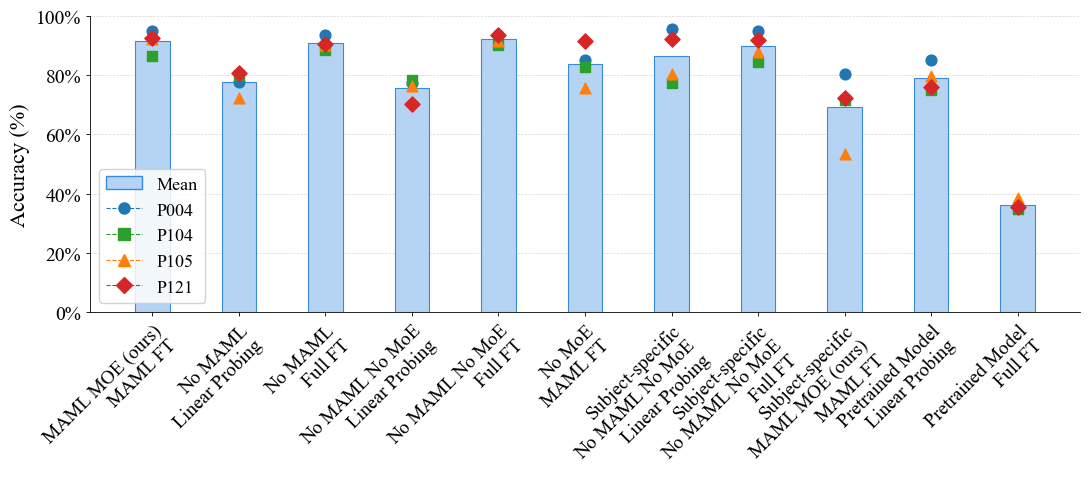

Saved fig1_main.pdf / .png


In [187]:
figure_main_ablations(df)


In [198]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── shared style ────────────────────────────────────────────────────────────
SUBJECTS = ['P004', 'P104', 'P105', 'P121']
SUBJECT_COLORS = {
    'P004': '#1f77b4',
    'P104': '#2ca02c',
    'P105': '#ff7f0e',
    'P121': '#d62728',
}
SUBJECT_MARKERS = {
    'P004': 'o',
    'P104': 's',
    'P105': '^',
    'P121': 'D',
}
BAR_FACE     = '#b5d4f4'
BAR_EDGE     = '#378add'
REF_BAR_FACE = '#d3d3d3'
REF_BAR_EDGE = '#888888'
OURS_BAR_FACE = '#f4c542'
OURS_BAR_EDGE = '#c49a00'

FONT_SIZE_TICKS        = 14
FONT_SIZE_LABELS       = 16
FONT_SIZE_LEGEND       = 12
FONT_SIZE_XTICKLABELS  = 12
FONT_SIZE_GROUP_LABEL  = 16


def _apply_common_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylabel('Accuracy (%)', fontsize=FONT_SIZE_LABELS)
    ax.tick_params(axis='both', labelsize=FONT_SIZE_TICKS)


def _subject_legend_handles(subjects):
    #handles = [
    #    mpatches.Patch(facecolor=OURS_BAR_FACE,  edgecolor=OURS_BAR_EDGE,  label='Mean (ours)'),
    #    mpatches.Patch(facecolor=BAR_FACE,        edgecolor=BAR_EDGE,        label='Mean (ablation)'),
    #    mpatches.Patch(facecolor=REF_BAR_FACE,    edgecolor=REF_BAR_EDGE,    label='Mean (reference)'),
    #]
    handles = []
    handles += [
        plt.Line2D([0], [0],
                   color=SUBJECT_COLORS[s],
                   marker=SUBJECT_MARKERS[s],
                   linestyle='--', linewidth=0.8, markersize=8, label=s)
        for s in subjects
    ]
    return handles


def _add_legend_with_backing(ax, handles):
    ax.legend(
        handles=handles,
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        framealpha=0.85,
        loc='lower left',
    )


def _get_best_row(group_df, force_method=None):
    """
    Return the single row with the highest Mean accuracy.
    If force_method is given, filter to that Finetune_Method first.
    Raises if the filtered group is empty.
    """
    if force_method is not None:
        group_df = group_df[group_df['Finetune_Method'] == force_method]
        assert len(group_df) > 0, f"No rows with Finetune_Method='{force_method}'"
    assert len(group_df) > 0, "Empty group passed to _get_best_row"
    return group_df.loc[group_df['Mean'].idxmax()]


def _draw_group_bracket(ax, x_positions, label, bar_width, y_frac=-0.18, color="#000000"):
    """
    Draw a horizontal bracket + label below the x-axis for a group of bars.
    y_frac is in axes-fraction units (negative = below axis).
    """
    x_left  = x_positions[0]  - bar_width / 2
    x_right = x_positions[-1] + bar_width / 2
    x_mid   = (x_left + x_right) / 2

    # Bracket line using mixed coords (data x, axes-fraction y)
    ax.annotate('',
                xy=(x_right, y_frac), xytext=(x_left, y_frac),
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.2),
                annotation_clip=False)

    # Label below the bracket — use annotate (not ax.text) so we can use
    # mixed coords without triggering the annotation_clip kwarg bug on ax.text
    ax.annotate(label,
                xy=(x_mid, y_frac - 0.04),
                xycoords=('data', 'axes fraction'),
                ha='center', va='top',
                fontsize=FONT_SIZE_GROUP_LABEL,
                color=color,
                annotation_clip=False)


def figure_main_ablations(df, save_prefix='fig1_main', show_lines=False):
    """
    Layout:
      GROUP 1 — 2x2 factorial (cross-subject), ordered worst→best:
        [No MAML No MoE] [No MAML + MoE] [MAML + No MoE] [MAML + MoE (ours)]
      — gap + divider —
      GROUP 2 — Subject-specific reference:
        [Subj-specific No MAML No MoE] [Subj-specific MAML + MoE]
      — gap + divider —
      GROUP 3 — Pretrained baseline:
        [Pretrained Model]

    Each bar shows the BEST finetune method (head vs full FT) for that ablation.
    M0 is forced to MAML finetune since that is its canonical training paradigm.
    """

    factorial_ids = ['A2', 'A1', 'A4', 'M0']
    reference_ids = ['A7', 'A8']
    baseline_ids  = ['A11']
    all_ids = factorial_ids + reference_ids + baseline_ids

    # M0's canonical method is MAML — don't let head/full override it
    force_method = {aid: None for aid in all_ids}
    force_method['M0'] = 'MAML'

    # Select best finetune row per ablation
    rows = []
    for aid in all_ids:
        group = df[df['Ablation_ID'] == aid]
        assert len(group) > 0, f"Ablation_ID '{aid}' not found in df"
        rows.append(_get_best_row(group, force_method=force_method[aid]))

    sub = {row['Ablation_ID']: row for row in rows}

    # Labels
    factorial_labels = [
        'No MAML\nNo MoE',
        'No MAML\nMoE',
        'MAML\nNo MoE',
        'MAML + MoE\n(ours)',
    ]
    reference_labels = [
        'Subj-specific\nNo MAML, No MoE',
        'Subj-specific\nMAML + MoE',
    ]
    baseline_labels = ['Pretrained\nModel']
    all_labels = factorial_labels + reference_labels + baseline_labels

    # x positions with gaps between groups
    bar_width   = 0.6
    group_gap   = 1.4

    factorial_x = np.arange(len(factorial_ids), dtype=float)
    reference_x = factorial_x[-1] + group_gap + np.arange(1, len(reference_ids) + 1, dtype=float)
    baseline_x  = reference_x[-1] + group_gap + np.arange(1, len(baseline_ids)  + 1, dtype=float)
    all_x = np.concatenate([factorial_x, reference_x, baseline_x])

    # Bar colors
    ours_id  = 'M0'
    ref_ids  = set(reference_ids + baseline_ids)
    bar_faces, bar_edges = [], []
    for aid in all_ids:
        if aid == ours_id:
            bar_faces.append(OURS_BAR_FACE); bar_edges.append(OURS_BAR_EDGE)
        elif aid in ref_ids:
            bar_faces.append(REF_BAR_FACE);  bar_edges.append(REF_BAR_EDGE)
        else:
            bar_faces.append(BAR_FACE);       bar_edges.append(BAR_EDGE)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig_width = all_x[-1] * 1.5 + 3
    fig, ax = plt.subplots(figsize=(fig_width, 5))

    for i, (aid, xi) in enumerate(zip(all_ids, all_x)):
        row = sub[aid]
        ax.bar(xi, row['Mean'] * 100, width=bar_width,
               color=bar_faces[i], edgecolor=bar_edges[i],
               linewidth=0.8, zorder=2)
        for subj in SUBJECTS:
            ax.scatter(xi, row[subj] * 100,
                       color=SUBJECT_COLORS[subj],
                       marker=SUBJECT_MARKERS[subj],
                       s=60, zorder=4)

    # Vertical dividers between groups
    for gap_x in [(factorial_x[-1] + reference_x[0]) / 2,
                  (reference_x[-1] + baseline_x[0]) / 2]:
        ax.axvline(gap_x, color='#aaaaaa', linestyle=':', linewidth=1.0, zorder=1)

    # Group bracket labels below x-axis
    _draw_group_bracket(ax, factorial_x, 'Cross-subject Ablations', bar_width)
    _draw_group_bracket(ax, reference_x, 'Subject-specific Baselines',              bar_width)
    _draw_group_bracket(ax, baseline_x,  'Pretrained Baseline',                     bar_width)

    # Axes
    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels, fontsize=FONT_SIZE_XTICKLABELS, ha='center')
    ax.set_ylim(0, 105)
    ax.set_xlim(all_x[0] - bar_width, all_x[-1] + bar_width)

    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)  # room for bracket labels — tune if needed

    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')

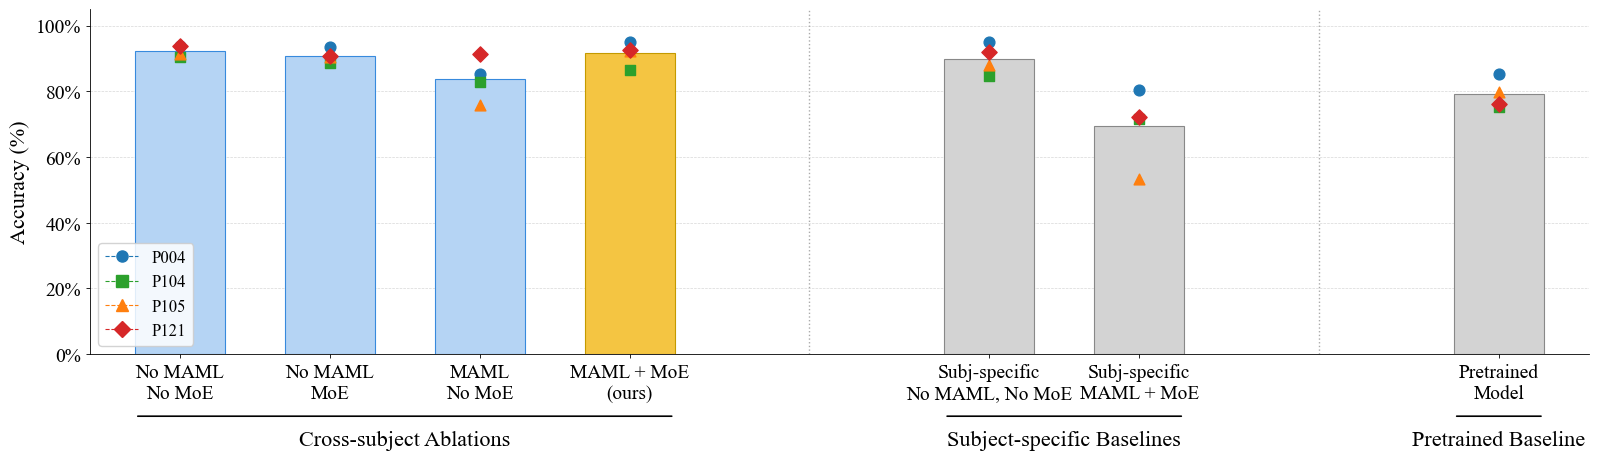

Saved fig1_main.pdf / .png


In [199]:
figure_main_ablations(df)

In [176]:
# ─── Figure 2: A5 — number of experts on x-axis ──────────────────────────────
def figure_num_experts(df, save_prefix='fig2_experts', show_lines=False):
    sub = df[df['Ablation_ID'].str.startswith('A5')].copy()

    def extract_experts(ablation_id):
        m = re.search(r'E(\d+)', ablation_id)
        assert m, f"Could not parse expert count from Ablation_ID: '{ablation_id}'"
        return int(m.group(1))

    sub['n_experts'] = sub['Ablation_ID'].apply(extract_experts)
    sub = sub.sort_values('n_experts')

    n = len(sub)
    bar_width = 0.4
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(5, n * 1.0), 5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        if show_lines:
            ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                    linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=60, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in sub['n_experts'].tolist()], fontsize=FONT_SIZE_XTICKLABELS)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Number of Experts', fontsize=FONT_SIZE_LABELS, labelpad=12)
    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS))

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')

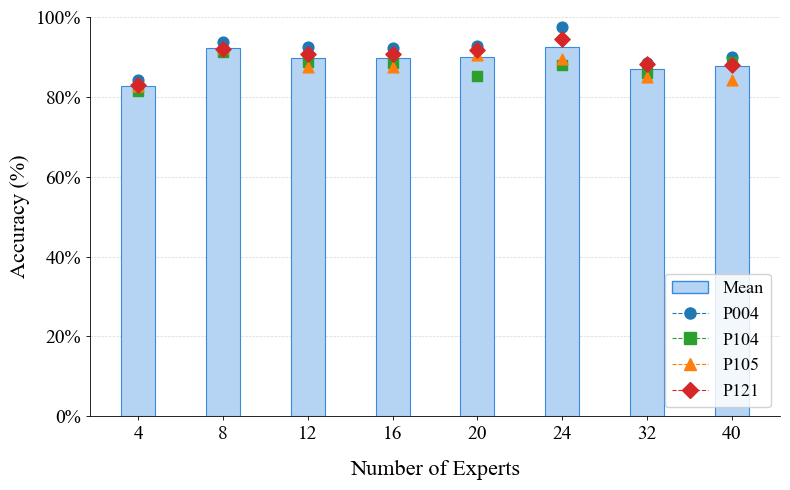

Saved fig2_experts.pdf / .png


In [136]:
figure_num_experts(df)


In [137]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

SUBJECTS        = USERS_TO_KEEP
SUBJECT_COLORS  = {'P004': '#e24b4a', 'P104': '#1d9e75', 'P105': '#534ab7', 'P121': '#ba7517'}
SUBJECT_MARKERS = {'P004': 'o',       'P104': 's',       'P105': '^',       'P121': 'D'}

def _apply_common_style(ax, fontsize=12):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.grid(axis='y', linewidth=0.5, color='#cccccc', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=fontsize)

def parse_grid(ablation_id):
    mk = re.search(r'k(\d+)', ablation_id)
    mn = re.search(r'n(\d+)', ablation_id)
    assert mk and mn, f"Could not parse k/n from Ablation_ID: '{ablation_id}'"
    return int(mk.group(1)), int(mn.group(1))

def figure_grid(df,
                show_maml=True,
                show_a2_head=True,
                show_a2_full=True,
                y_baseline='chance',   # 'chance', 0, or a fixed int/float
                save_prefix='fig_grid'):
    """
    Compares mainline grid (MAML) vs grid_A2 (head / full finetune).

    Parameters
    ----------
    show_maml    : include mainline MAML bars
    show_a2_head : include A2 head-only bars
    show_a2_full : include A2 full-finetune bars
    y_baseline   : 'chance' (1/n_way per group), 0, or a fixed number
    """

    # ── Pull and parse the two sub-DataFrames ────────────────────────────────
    main = df[df['Ablation_ID'].str.match(r'^grid_k\d+_n\d+$')].copy()
    a2   = df[df['Ablation_ID'].str.match(r'^grid_A2_k\d+_n\d+$')].copy()

    assert not main.empty, "No mainline grid rows found in df"
    assert not a2.empty,   "No grid_A2 rows found in df"

    for sub in (main, a2):
        sub[['k_shot', 'n_way']] = sub['Ablation_ID'].apply(
            lambda a: pd.Series(parse_grid(a)))

    k_values = sorted(main['k_shot'].unique())
    n_values = sorted(main['n_way'].unique())

    # ── Series config: (key, label, dataframe, ft_label, color) ─────────────
    all_series = [
        ('maml', 'MAML MOE',    main, 'MAML', '#3266ad'),
        ('head', 'CNN-LSTM: Head FT', a2,   'head', '#c0560a'),
        ('full', 'CNN-LSTM: Full FT', a2,   'full', '#2a8a5e'),
    ]
    show_flags = {'maml': show_maml, 'head': show_a2_head, 'full': show_a2_full}
    series = [(k, l, d, f, c) for k, l, d, f, c in all_series if show_flags[k]]
    n_series = len(series)

    # ── Bar geometry ──────────────────────────────────────────────────────────
    # Layout: [n_way group] -> [k_shot cluster] -> [series bars]
    # Between n_way groups: padding_frac * total cluster width
    bar_width      = 0.18
    series_gap     = 0.04                           # gap between series within a k cluster
    k_cluster_w    = n_series * bar_width + (n_series - 1) * series_gap
    k_gap          = 0.25                           # gap between k clusters within an n group
    n_group_w      = len(k_values) * k_cluster_w + (len(k_values) - 1) * k_gap
    n_padding      = 0.6                            # whitespace between n-way groups
    n_step         = n_group_w + n_padding          # total x-distance between group centers

    # Center of each n-way group
    n_centers = np.arange(len(n_values)) * n_step

    # Offsets for each k cluster relative to its n-way group center
    k_cluster_starts = {}
    total_k_width = len(k_values) * k_cluster_w + (len(k_values) - 1) * k_gap
    for ki, k in enumerate(k_values):
        k_cluster_starts[k] = -total_k_width / 2 + ki * (k_cluster_w + k_gap)

    # Offsets for each series bar relative to its k cluster start
    series_offsets = {}
    for si, (s_key, *_) in enumerate(series):
        series_offsets[s_key] = si * (bar_width + series_gap)

    k_colors = {k: c for k, c in zip(k_values,
                ['#4878d0', '#ee854a', '#6acc65', '#d65f5f', '#956cb4'])}

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig_w = max(10, len(n_values) * (n_group_w + n_padding) * 1.8)
    fig   = plt.figure(figsize=(fig_w, 10))
    gs    = GridSpec(2, 2, figure=fig, height_ratios=[2.5, 1],
                     hspace=0.5, wspace=0.35)

    ax_bar   = fig.add_subplot(gs[0, :])
    ax_hhead = fig.add_subplot(gs[1, 0])
    ax_hfull = fig.add_subplot(gs[1, 1])

    # ── Bar chart ─────────────────────────────────────────────────────────────
    for ni, n in enumerate(n_values):
        for ki, k in enumerate(k_values):
            k_x0 = n_centers[ni] + k_cluster_starts[k]

            for s_key, s_label, s_df, ft_label, s_color in series:
                match = s_df[(s_df['k_shot'] == k) &
                             (s_df['n_way']  == n) &
                             (s_df['Finetune_Method'] == ft_label)]
                if match.empty:
                    continue
                assert len(match) == 1, \
                    f"Multiple rows for series={s_label}, k={k}, n={n}"

                xpos     = k_x0 + series_offsets[s_key] + bar_width / 2
                mean_val = match['Mean'].values[0] * 100

                bar_label = s_label if (ni == 0 and ki == 0) else '_nolegend_'
                ax_bar.bar(xpos, mean_val, width=bar_width,
                           color=s_color, alpha=0.85,
                           edgecolor='white', linewidth=0.6,
                           zorder=2, label=bar_label)

                for subj in SUBJECTS:
                    sv = match[subj].values[0] * 100
                    ax_bar.scatter(xpos, sv,
                                   color=SUBJECT_COLORS[subj],
                                   marker=SUBJECT_MARKERS[subj],
                                   s=35, zorder=4, linewidths=0.5,
                                   edgecolors='white')

    # ── x-axis ticks at n-way group centers ───────────────────────────────────
    ax_bar.set_xticks(n_centers)
    ax_bar.set_xticklabels([f'{n}-way' for n in n_values], fontsize=13)
    ax_bar.set_xlabel('$n$-way classification', fontsize=13)
    ax_bar.set_ylabel('Accuracy', fontsize=13)

    # ── y baseline ────────────────────────────────────────────────────────────
    if y_baseline == 'chance':
        # Draw a per-group chance line since n_way differs per group
        for ni, n in enumerate(n_values):
            chance = 100 / n
            half_w = n_group_w / 2 + k_gap / 2
            ax_bar.hlines(chance,
                          n_centers[ni] - half_w, n_centers[ni] + half_w,
                          colors='#888888', linestyles='--',
                          linewidth=1.0, zorder=3,
                          label='Chance' if ni == 0 else '_nolegend_')
        y_min = max(0, min(100 / n for n in n_values) - 5)
    else:
        y_min = int(y_baseline)

    ax_bar.set_ylim(y_min, 102)
    ax_bar.set_xlim(n_centers[0] - n_group_w / 2 - n_padding / 2,
                    n_centers[-1] + n_group_w / 2 + n_padding / 2)
    _apply_common_style(ax_bar, fontsize=12)

    # ── k-shot sub-labels below x-axis ────────────────────────────────────────
    for ni, n in enumerate(n_values):
        for ki, k in enumerate(k_values):
            k_x0      = n_centers[ni] + k_cluster_starts[k]
            k_x_mid   = k_x0 + k_cluster_w / 2
            ax_bar.text(k_x_mid, y_min - (102 - y_min) * 0.055,
                        f'k={k}', ha='center', va='top',
                        fontsize=10, fontweight='bold',
                        #color=k_colors[k]
                        color='black'
                        )

    # ── Legend ────────────────────────────────────────────────────────────────
    s_handles = [mpatches.Patch(facecolor=c, alpha=0.85, label=l)
                 for _, l, _, _, c in series]
    subj_handles = [
        plt.Line2D([0], [0], color=SUBJECT_COLORS[s], marker=SUBJECT_MARKERS[s],
                   linestyle='None', markersize=7, label=s)
        for s in SUBJECTS
    ]
    chance_handle = [mpatches.Patch(facecolor='none', edgecolor='#888888',
                                    linestyle='--', label='Chance')]
    all_handles = s_handles + (chance_handle if y_baseline == 'chance' else []) + subj_handles

    ax_bar.legend(handles=all_handles, fontsize=10, frameon=True,
                  facecolor='white', edgecolor='#cccccc',
                  loc='lower left', ncol=2, framealpha=0.9)

    # ── Difference heatmaps ───────────────────────────────────────────────────
    def build_delta_matrix(ft_label):
        mat = np.full((len(k_values), len(n_values)), np.nan)
        for ki, k in enumerate(k_values):
            for ni, n in enumerate(n_values):
                m_row = main[(main['k_shot'] == k) & (main['n_way'] == n) &
                             (main['Finetune_Method'] == 'MAML')]
                a_row = a2[(a2['k_shot'] == k) & (a2['n_way'] == n) &
                           (a2['Finetune_Method'] == ft_label)]
                if m_row.empty or a_row.empty:
                    continue
                mat[ki, ni] = (a_row['Mean'].values[0] - m_row['Mean'].values[0]) * 100
        return mat

    def draw_heatmap(ax, mat, title):
        vmax = max(np.nanmax(np.abs(mat)), 0.1)
        im   = ax.imshow(mat, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(n_values)))
        ax.set_yticks(range(len(k_values)))
        ax.set_xticklabels([f'{n}-way' for n in n_values], fontsize=11)
        ax.set_yticklabels([f'k={k}' for k in k_values], fontsize=11)
        ax.set_xlabel('$n$-way', fontsize=11)
        ax.set_title(title, fontsize=12, pad=8)
        for ki in range(len(k_values)):
            for ni in range(len(n_values)):
                v = mat[ki, ni]
                if not np.isnan(v):
                    ax.text(ni, ki, f'{v:+.1f}', ha='center', va='center',
                            fontsize=10,
                            color='white' if abs(v) > vmax * 0.6 else '#222222')
        plt.colorbar(im, ax=ax, shrink=0.85, label='Δ pp (A2 − MAML)')

    draw_heatmap(ax_hhead, build_delta_matrix('head'), 'A2 head − MAML (pp)')
    draw_heatmap(ax_hfull, build_delta_matrix('full'), 'A2 full − MAML (pp)')

    plt.suptitle('Grid sweep: MAML vs A2 (head / full)', fontsize=14, y=1.01)
    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


C:\Users\kdmen\AppData\Local\Temp\ipykernel_42528\783163973.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


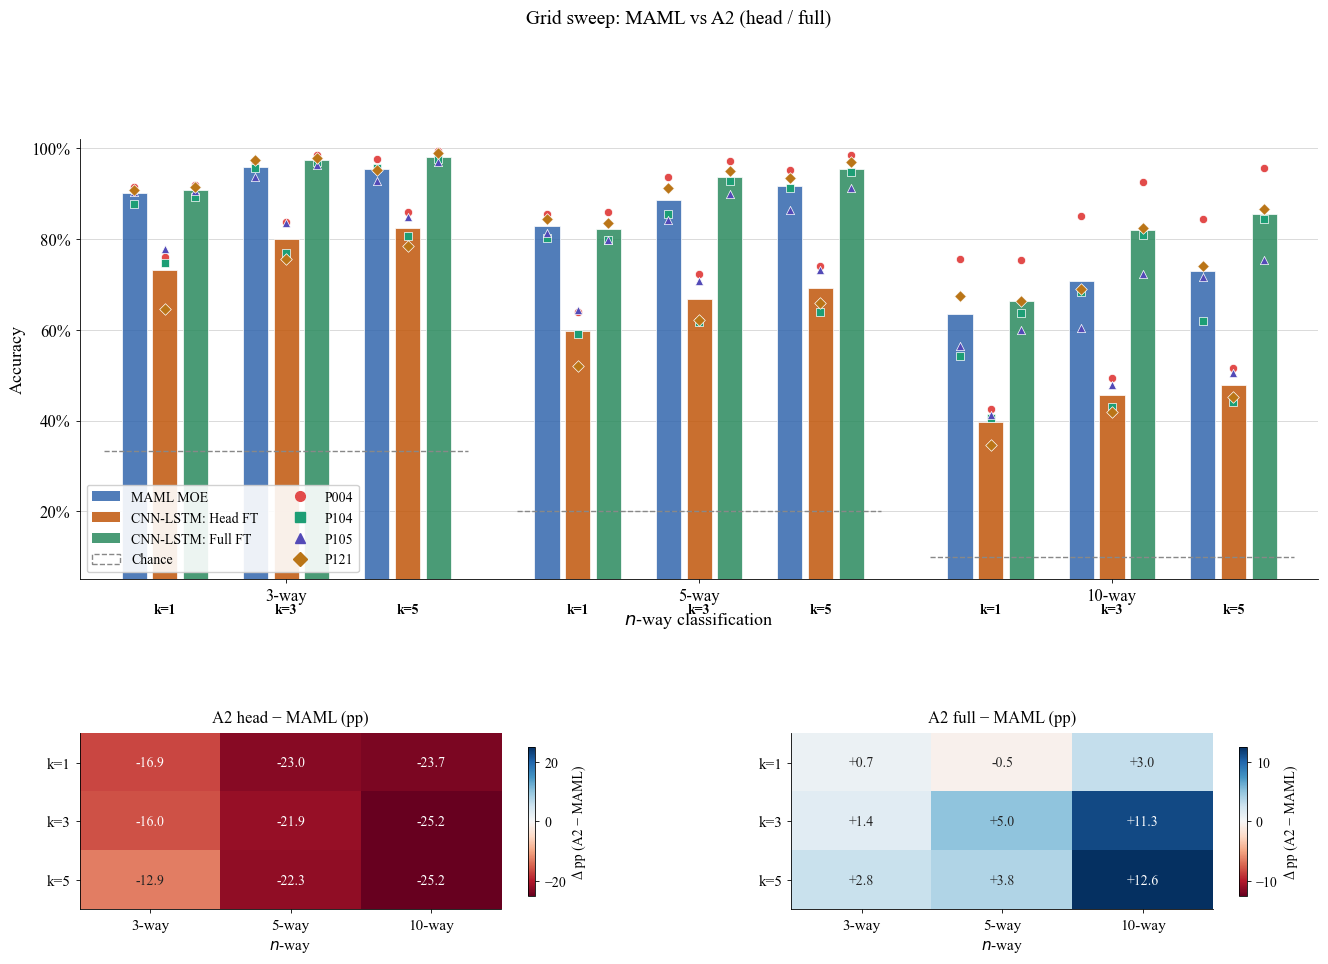

Saved fig_grid.pdf / .png


In [138]:
# Example calls
figure_grid(df)                        # all three, chance baseline (recommended)
#figure_grid(df, y_baseline=0)          # start from 0%
#figure_grid(df, show_a2_head=False)    # drop A2 head once you've decided

In [ ]:
# FIGURE: Main Figure: M0 vs Key Ablations
## This should probably be a table actually

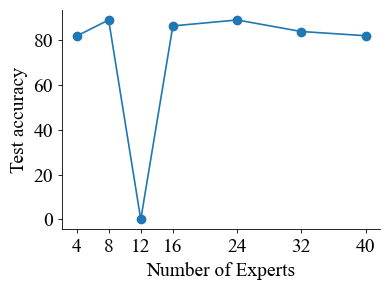

In [ ]:
# FIGURE: Num Experts Sweep (Line Plot)
## Ideally is a mountain curve around 22ish?

A5_num_experts_sweep_dict = {
    4: 81.80,   # (at 20 was 78.17...)
    8: 88.99,  # (at 20 was 89.42 lol)
    12: 0.0, 
    16: 86.34, 
    #20: 88.42, 
    24: 88.99, 32: 83.84, 40: 81.96, 
}

TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13 + 1

# ── Figure layout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.0))

ax.plot(
    list(A5_num_experts_sweep_dict.keys()),
    list(A5_num_experts_sweep_dict.values()),
    #color=color,
    #label=label,
    linewidth=1.2,
)
ax.scatter(
    list(A5_num_experts_sweep_dict.keys()),
    list(A5_num_experts_sweep_dict.values()),
    #color=color,
    #label=label,
)

ax.set_xticks(list(A5_num_experts_sweep_dict.keys()))
ax.set_xlabel("Number of Experts", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Test accuracy", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

plt.tight_layout()

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("num_experts_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("num_experts_sweep.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
# FIGURE: K-shot N-way Performance Grid (Line Plot)
## Need to show best baseline here as well

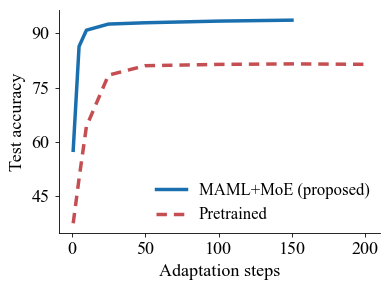

In [200]:
# FIGURE: Eval Num Steps Sweep (Line Plot)
## I dont have error bars for this rn... maybe the json has the mean and std?

# A11 eval sweep (LR=0.01)
A11_eval_sweep_dict = {1: 37.60, 5: 49.93, 10: 64.29, 25: 78.47, 50: 81.08, 100: 81.44, 150: 81.58, 200: 81.46}

# A7 eval sweep (LR=0.001)
# --> gonna ignore this one because it was not using paired corresponding user-specific models
A7_eval_sweep_dict = {1: 39.35, 5: 63.15, 10: 72.80, 25: 77.23, 50: 78.13, 100: 78.27, 150: 78.30, 200: 78.41}

# M0 eval sweep
M0_eval_sweep_dict = {1: 57.73, 5: 86.40, 10: 90.88, 25: 92.57, 50: 92.93, 100: 93.39, 150: 93.65}



COLORS = ["#1a6faf", "#2ca25f", "#c44e52"]
DASHES = [(), (6, 2), (3, 2)]

TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13

# ── Figure layout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.0))

lines = [
    (M0_eval_sweep_dict,  "MAML+MoE (proposed)",         COLORS[0], DASHES[0]),
    #(A7_eval_sweep_dict,  "Subject-specific",   COLORS[1], DASHES[1]),
    (A11_eval_sweep_dict, "Pretrained", COLORS[2], DASHES[2]),
]

for data, label, color, dash in lines:
    ax.plot(
        list(data.keys()),
        list(data.values()),
        color=color,
        dashes=dash,
        label=label,
        linewidth=2.5,
    )

ax.set_xlabel("Adaptation steps", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Test accuracy", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="lower right", handlelength=1.8, borderaxespad=0.2, fontsize=LABEL_FONTSIZE-1)

plt.tight_layout()

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("eval_steps_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("eval_steps_sweep.png", dpi=500, bbox_inches="tight")
plt.show()

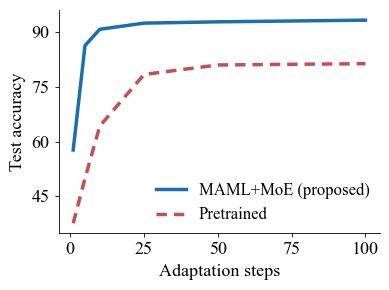

In [ ]:
# FIGURE: Eval Num Steps Sweep (Line Plot)
## I dont have error bars for this rn... maybe the json has the mean and std?

# A11 eval sweep (LR=0.01)
A11_eval_sweep_dict = {1: 37.60, 5: 49.93, 10: 64.29, 25: 78.47, 50: 81.08, 100: 81.44}  #, 150: 81.58, 200: 81.46}

# A7 eval sweep (LR=0.001)
# --> gonna ignore this one because it was not using paired corresponding user-specific models
A7_eval_sweep_dict = {1: 39.35, 5: 63.15, 10: 72.80, 25: 77.23, 50: 78.13, 100: 78.27, 150: 78.30, 200: 78.41}

# M0 eval sweep
M0_eval_sweep_dict = {1: 57.73, 5: 86.40, 10: 90.88, 25: 92.57, 50: 92.93, 100: 93.39} #, 150: 93.65}



COLORS = ["#1a6faf", "#2ca25f", "#c44e52"]
DASHES = [(), (6, 2), (3, 2)]

TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13

# ── Figure layout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.0))

lines = [
    (M0_eval_sweep_dict,  "MAML+MoE (proposed)",         COLORS[0], DASHES[0]),
    #(A7_eval_sweep_dict,  "Subject-specific",   COLORS[1], DASHES[1]),
    (A11_eval_sweep_dict, "Pretrained", COLORS[2], DASHES[2]),
]

for data, label, color, dash in lines:
    ax.plot(
        list(data.keys()),
        list(data.values()),
        color=color,
        dashes=dash,
        label=label,
        linewidth=2.5,
    )

ax.set_xlabel("Adaptation steps", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Test accuracy", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="lower right", handlelength=1.8, borderaxespad=0.2, fontsize=LABEL_FONTSIZE-1)

plt.tight_layout()

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("eval_steps_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("eval_steps_sweep.png", dpi=500, bbox_inches="tight")
plt.show()